# Set up

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

✓ Workspace ready


In [2]:
import matplotlib
from matplotlib.ticker import ScalarFormatter
from scipy.special import voigt_profile

# Functions

In [3]:
def Polydisperse_PLD(q, L_c, I_0, p, bkg):
    sigma = p*L_c
    L = np.arange(max((L_c - 3*sigma), 0.00001), L_c + 3*sigma, 0.05)
    
    I_PD = 0*q
    for i in L:
        I_PD += normal(i, L_c, sigma)*PLD(q, i, I_0)
    return I_PD+bkg

# Data

## PCL

In [10]:
PCL_M1_saxs = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00065_00_ave.h5")
PCL_M2_saxs = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00077_00_ave.h5")
PCL_M3_saxs = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00090_00_ave.h5")
PCL_M4_saxs = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00102_00_ave.h5")
# PCL_M2_saxs = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00077_00_av_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)
# PCL_M3_saxs = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00090_00_av_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)
# PCL_M4_saxs = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00102_00_av_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)

PCL_M1_saxs_melt = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00075_00_ave.h5")
PCL_M2_saxs_melt = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00087_00_ave.h5")
PCL_M3_saxs_melt = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00099_00_ave.h5")
PCL_M4_saxs_melt = ID02_experiment(r"E:\PEG_PCL\sc5665\PEG_eiger2_00111_00_ave.h5")
# PCL_M1_saxs_melt = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00075_00_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)
# PCL_M2_saxs_melt = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00087_00_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)
# PCL_M3_saxs_melt = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00099_00_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)
# PCL_M3_20perc_saxs_melt = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00053_00_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)
# PCL_M4_saxs_melt = pd.read_table("E:\PEG_PCL\sc5665 static data\PEG_eiger2_00111_00_c.dat", sep='\t', names=['q', 'I', 'error'], skiprows=1)

NameError: name 'p3' is not defined

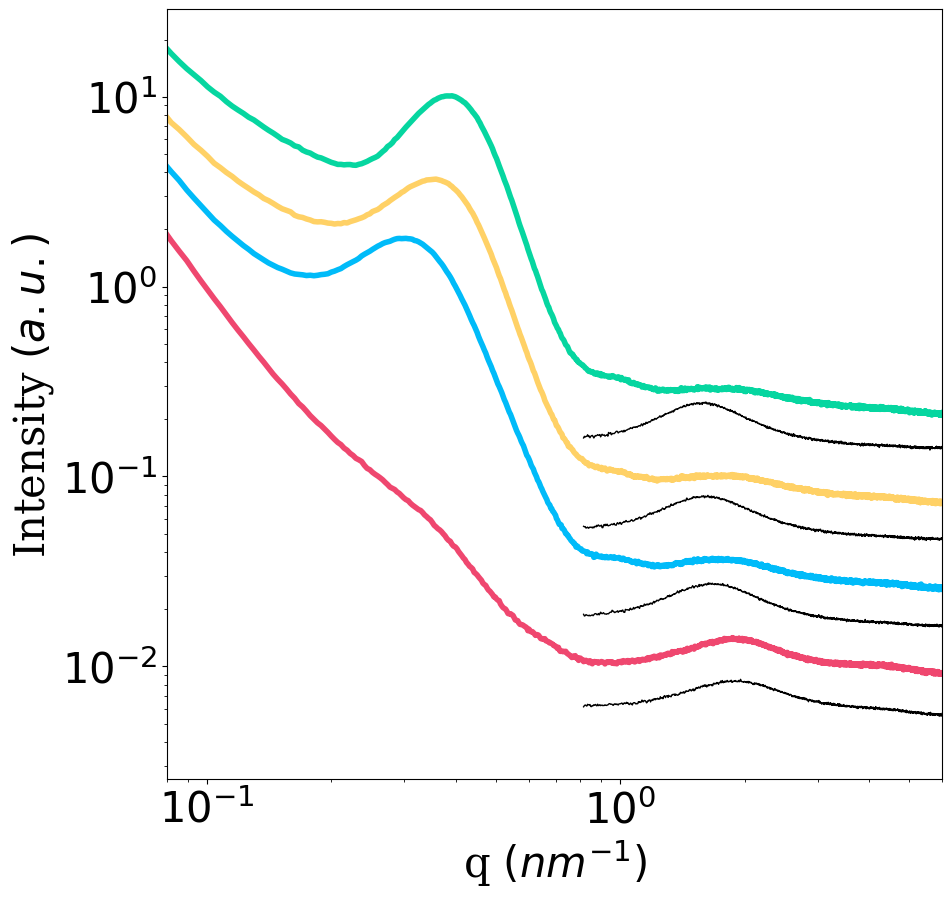

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))
font = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }
plt.xticks([0.1, 0.5, 1, 2], fontsize=30)
plt.yticks([0.1, 1, 10, 100], fontsize=30)

plt.semilogx()
plt.semilogy()
plt.xlim(0.08, 6)
#plt.ylim(0.02, 500)

plt.xlabel('q $(nm^{-1})$', fontdict = font)
plt.ylabel('Intensity $(a.u.)$', fontdict = font)

q, I = PCL_M1_saxs.get_1d_data()
plt.plot(q, I[0]*3, linewidth=4, color='#00bbf9', label='PCL M1', zorder=1)

q, I = PCL_M2_saxs.get_1d_data()
plt.plot(q, I[0], linewidth=4, color='#EF476F', label='PCL M2', zorder=0)

q, I = PCL_M3_saxs.get_1d_data()
plt.plot(q, I[0]*9, linewidth=4, color='#FFD166', label='PCL M3', zorder=1)

q, I = PCL_M4_saxs.get_1d_data()
plt.plot(q, I[0]*27, linewidth=4, color='#06D6A0', label='PCL M4', zorder=1)


l = 200
r = 1000

q, I = PCL_M1_saxs_melt.get_1d_data()
plt.plot(q[l:], I[0][l:]*3 / 1.8, linewidth=1,  color='#000000', zorder=1)

q, I = PCL_M2_saxs_melt.get_1d_data()
plt.plot(q[l:], I[0][l:] / 1.8, linewidth=1, color='#000000', zorder=0)

q, I = PCL_M3_saxs_melt.get_1d_data()
plt.plot(q[l:], I[0][l:]*9 / 1.8, linewidth=1, color='#000000',  zorder=1)

q, I = PCL_M4_saxs_melt.get_1d_data()
plt.plot(q[l:], I[0][l:]*27 / 1.8, linewidth=1, color='#000000', zorder=1)

#plt.plot(PCL_M1_saxs_melt['q'][l:r], PCL_M1_saxs_melt['I'][l:r]*3/1.5, linewidth=1, color='#00bbf9', zorder=-1)
#plt.plot(PCL_M2_saxs_melt['q'][l:r], PCL_M2_saxs_melt['I'][l:r]/1.5, linewidth=1, color='#EF476F', zorder=-2)
#plt.plot(PCL_M3_saxs_melt['q'][l:r], PCL_M3_saxs_melt['I'][l:r]*9/1.5, linewidth=1, color='#FFD166', zorder=-1)
#plt.plot(PCL_M4_saxs_melt['q'][l:r], PCL_M4_saxs_melt['I'][l:r]*27/2, linewidth=1, color='#06D6A0',  zorder=-1)


plt.plot(q[150:300], Polydisperse_PLD(q, *p3)[150:300]*9, ':', linewidth=3, color='black')
#plt.plot(x[150:300], Polydisperse_PLD(x, *p4)[150:300]*27, ':', linewidth=3, color='black')
#plt.plot(x[150:300], Polydisperse_PLD(x, *p1)[150:300]*3, ':', linewidth=3, color='black')

ax.tick_params(axis="both",which='both',direction="in", width=3, length=3)
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
#ax.minorticks_off()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    
plt.legend(fontsize=20)